# Example 4 - Spatial variation of Curie depth

Mapping Curie depth means repeating the fit of [Ex2](./Ex2-Compute-Curie-depth.ipynb) over a grid of overlapping windows. `create_centroid_list` lays out the centroids and `optimise_routine` runs them in parallel, returning one array per quantity — including one per uncertainty, so a map of $\sigma$ comes out alongside the map of the parameter.

The synthetic used here has a Curie depth that is **the same everywhere**, 21 km. Every feature in the maps below is therefore an artefact, and the point of the notebook is to see how large those artefacts are before trusting a map made from real data.

### Contents

- [Laying out the windows](#Laying-out-the-windows)
- [Mapping the parameters](#Mapping-the-parameters)
- [The Curie depth map](#The-Curie-depth-map)
- [How much of this is real?](#How-much-of-this-is-real)
- [Uncertainty at a single window](#Uncertainty-at-a-single-window)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pycurious

## Laying out the windows

A window has to be several times the Curie depth to constrain the thickness of the layer at all, and the grid has to be several times the window to hold more than one of them. That is a demanding combination, and it is why Curie depth maps are coarse.

Here a 4092 km grid carries 1200 km windows on a 300 km spacing.

In [2]:
beta_true, zt_true, dz_true = 3.0, 1.0, 20.0
CPD_true = zt_true + dz_true

data, extent = pycurious.fractal_anomaly(
    n=1024, dx=4.0, beta=beta_true, zt=zt_true, dz=dz_true, C=5.0, seed=1)

grid = pycurious.CurieOptimiseBouligand(data, *extent)

window_size = 1200e3
xc_list, yc_list = grid.create_centroid_list(
    window_size, spacingX=300e3, spacingY=300e3)

print("grid {:.0f} km across, {:.0f} km windows, {} centroids".format(
    (extent[1] - extent[0])*1e-3, window_size*1e-3, len(xc_list)))
print("true Curie depth is {:.1f} km at every one of them".format(CPD_true))

grid 4092 km across, 1200 km windows, 100 centroids
true Curie depth is 21.0 km at every one of them


In [3]:
beta, zt, dz, C, sigma_beta, sigma_zt, sigma_dz, sigma_C = grid.optimise_routine(
    window_size, xc_list, yc_list, taper=np.hanning)

nx = len(np.unique(xc_list))
ny = len(np.unique(yc_list))
shape = (ny, nx)
map_extent = np.array([xc_list.min(), xc_list.max(),
                       yc_list.min(), yc_list.max()])*1e-3

/Users/ben/git/pycurious/pycurious/parallel.py:78: RuntimeWarning: zt converged onto its bound at 0, so its uncertainty is not meaningful -- the fit was not free to move it.
  res = func(*pass_args, **call_kwargs)


One window raised a warning: at that centroid the fit pushed $z_t$ onto its lower bound of zero, so the curvature the uncertainty is derived from describes a solution the optimiser was not free to find. `pycurious` says so rather than reporting a meaningless $\sigma$ silently.

## Mapping the parameters

Each parameter beside its uncertainty. Remember that the true value is constant across all of these.

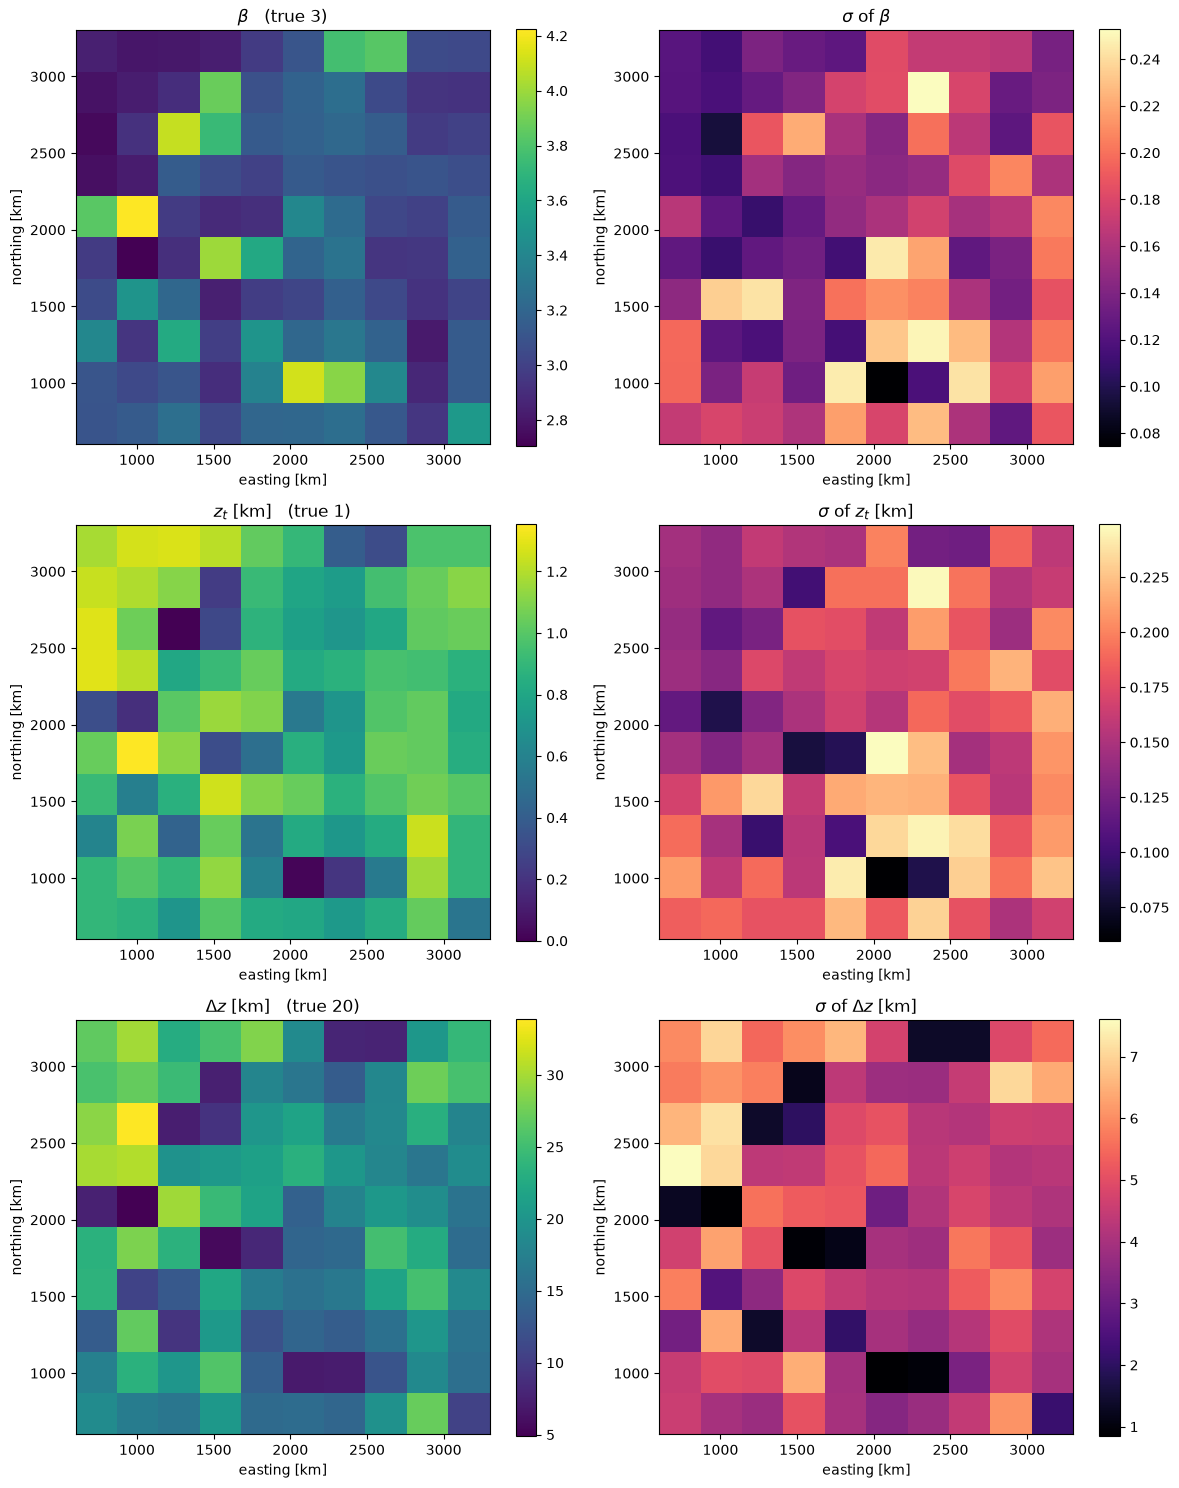

In [4]:
fields = [(beta, sigma_beta, r'$\beta$', beta_true),
          (zt, sigma_zt, r'$z_t$ [km]', zt_true),
          (dz, sigma_dz, r'$\Delta z$ [km]', dz_true)]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for row, (value, sigma, label, truth) in enumerate(fields):
    im = axes[row, 0].imshow(value.reshape(shape), extent=map_extent,
                             origin='lower', cmap='viridis')
    axes[row, 0].set_title('{}   (true {:g})'.format(label, truth))
    fig.colorbar(im, ax=axes[row, 0])

    im = axes[row, 1].imshow(sigma.reshape(shape), extent=map_extent,
                             origin='lower', cmap='magma')
    axes[row, 1].set_title(r'$\sigma$ of ' + label)
    fig.colorbar(im, ax=axes[row, 1])

for ax in axes.ravel():
    ax.set_xlabel('easting [km]')
    ax.set_ylabel('northing [km]')

plt.tight_layout()
plt.show()

## The Curie depth map

`calculate_CPD` combines the two depths and their uncertainties, and vectorises over the whole map.

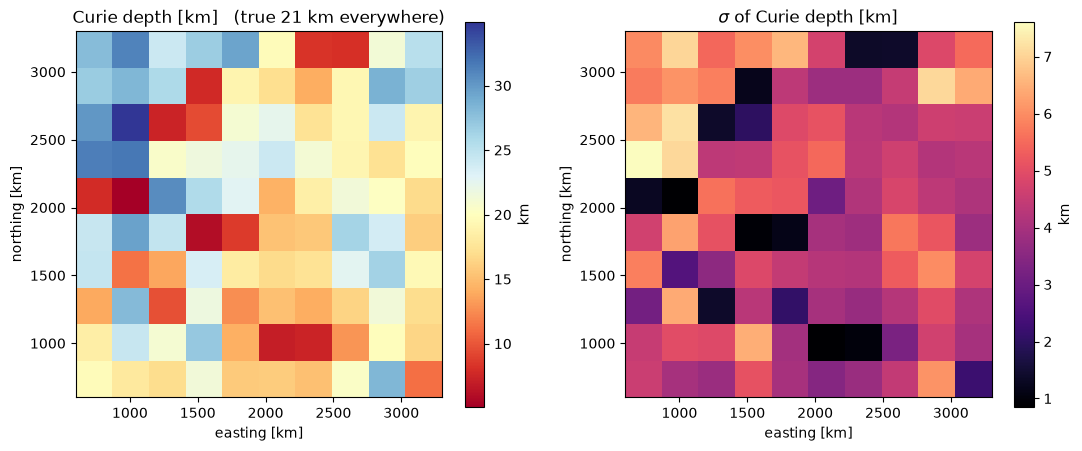

In [5]:
CPD, sigma_CPD = grid.calculate_CPD(zt, dz, sigma_zt, sigma_dz)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im1 = ax1.imshow(CPD.reshape(shape), extent=map_extent, origin='lower',
                 cmap='RdYlBu')
ax1.set_title('Curie depth [km]   (true {:.0f} km everywhere)'.format(CPD_true))
fig.colorbar(im1, ax=ax1, label='km')

im2 = ax2.imshow(sigma_CPD.reshape(shape), extent=map_extent, origin='lower',
                 cmap='magma')
ax2.set_title(r'$\sigma$ of Curie depth [km]')
fig.colorbar(im2, ax=ax2, label='km')

for ax in (ax1, ax2):
    ax.set_xlabel('easting [km]')
    ax.set_ylabel('northing [km]')
plt.show()

## How much of this is real?

None of it.

In [6]:
print("true Curie depth      {:6.2f} km everywhere".format(CPD_true))
print("mapped, mean          {:6.2f} km".format(CPD.mean()))
print("mapped, range         {:6.2f} to {:.2f} km".format(CPD.min(), CPD.max()))
print("mapped, std deviation {:6.2f} km".format(CPD.std()))
print("mean reported sigma   {:6.2f} km".format(sigma_CPD.mean()))

true Curie depth       21.00 km everywhere
mapped, mean           19.58 km
mapped, range           5.10 to 34.94 km
mapped, std deviation   6.66 km
mean reported sigma     4.38 km


A field with a Curie depth of exactly 21 km everywhere produces a map running from 5 km to 35 km — a factor of seven, with structure that looks entirely plausible as geology. The mean is close to the truth, but no individual window is reliable.

Two things are worth taking from this.

**The apparent variation is a noise floor, not a signal.** Before reading a low in a real Curie depth map as thinned crust or elevated heat flow, the variation has to exceed what the method invents on a field with no variation at all. Here that floor is about 6.7 km standard deviation.

**The scatter is wider than the reported uncertainty.** The windows scatter by 6.7 km while reporting an average $\sigma$ of 4.4 km. That gap is the long tail of $\Delta z$ again: a symmetric $\sigma$ cannot describe a distribution that reaches much further up than down, so it understates the spread. `profile` gives the honest interval at any window that matters.

Note also that these windows are 1200 km wide on a 300 km spacing, so each overlaps its neighbours by three quarters. Adjacent estimates share most of their data and are strongly correlated — the maps are smoother than independent sampling would give, and that smoothness is not evidence that the features are real either.

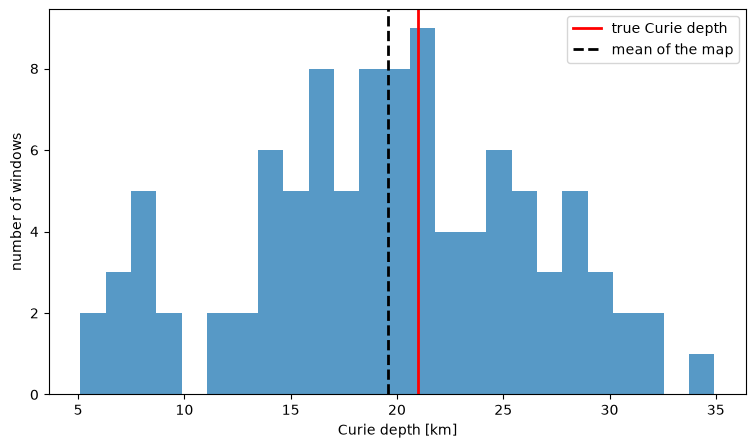

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(CPD, bins=25, color='C0', alpha=0.75)
ax.axvline(CPD_true, color='r', lw=2, label='true Curie depth')
ax.axvline(CPD.mean(), color='k', ls='--', lw=2, label='mean of the map')
ax.set_xlabel('Curie depth [km]')
ax.set_ylabel('number of windows')
ax.legend()
plt.show()

## Uncertainty at a single window

For one window the full machinery of [Ex3](./Ex3-Posing-the-inverse-problem.ipynb) is available. `sensitivity` resamples the spectrum; `profile` gives an asymmetric interval; both are far more informative than the single number the map carries.

In [8]:
xpt = 0.5*(extent[0] + extent[1])
ypt = 0.5*(extent[2] + extent[3])

posterior = np.array(grid.sensitivity(
    window_size, xpt, ypt, 300, taper=np.hanning, seed=1))
cpd_samples = posterior[1] + posterior[2]

_, _, lower, upper = grid.profile(
    window_size, xpt, ypt, "CPD", level=0.95, taper=np.hanning)

print("resampled Curie depth  {:.2f} +/- {:.2f} km".format(
    cpd_samples.mean(), cpd_samples.std()))
print("profile 95% interval   [{:.2f}, {:.2f}] km".format(lower, upper))
print("true                   {:.2f} km".format(CPD_true))

resampled Curie depth  15.20 +/- 2.39 km
profile 95% interval   [10.63, 20.83] km
true                   21.00 km


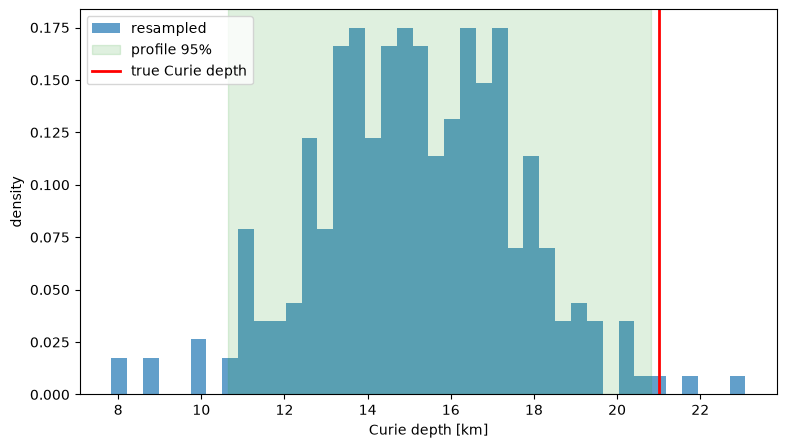

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cpd_samples, bins=40, density=True, alpha=0.7, label='resampled')
ax.axvspan(lower, upper, color='C2', alpha=0.15, label='profile 95%')
ax.axvline(CPD_true, color='r', lw=2, label='true Curie depth')
ax.set_xlabel('Curie depth [km]')
ax.set_ylabel('density')
ax.legend()
plt.show()

This window is a good illustration of the notebook's point, because it is one of the unlucky ones: the true 21 km sits just outside the 95% interval, which reaches only to 20.8 km. A 95% interval is wrong one time in twenty by construction, and with 100 windows on this map several are expected to miss.

That is not a reason to distrust the interval — it is the interval behaving exactly as advertised. It *is* a reason not to build an interpretation on any single window.

### Summary

- `optimise_routine` returns a $\sigma$ map alongside every parameter map. Plot them together; a feature that is not large compared with its own uncertainty is not a feature.
- Test the method against a synthetic with no variation before interpreting variation in real data. On this grid a constant 21 km Curie depth maps as 5-35 km.
- Overlapping windows produce smooth maps whether or not anything smooth is there.
- The map's per-window $\sigma$ understates the spread, because the Curie depth's uncertainty is asymmetric. Use `profile` wherever a number is going to be relied on.
- A 95% interval misses one time in twenty. On a map of 100 windows, expect several to exclude the truth.